# Montgomery County CXR — raw data exploration (lung-field segmentation)

Reads the **raw** NIH download straight off disk.

* `MontgomerySet/CXR_png/*.png` — frontal chest X-rays, **grayscale `uint8` 0-255**,
  very large (~4000×4900), and orientation is not consistent (some are transposed).
* `MontgomerySet/ManualMask/{leftMask,rightMask}/*.png` — per-lung boolean masks.
  Combined (`left | right`) they give the lung field.
* `MontgomerySet/ClinicalReadings/*.txt` — per-patient notes (not used here).

Task here: **binary** — background vs. lung field (channels 1 = left, 2 = right are
also available; see `LR_SPLIT`). 138 images, no official train/test split.

In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

_CAND = ['../../data/MontgomeryCXR/raw', 'data_handlers/data/MontgomeryCXR/raw',
         '../data_handlers/data/MontgomeryCXR/raw']
RAW = next((p for p in _CAND if os.path.isdir(p)), _CAND[0])
BASE = os.path.join(RAW, 'MontgomerySet')
print('raw root :', os.path.abspath(RAW), '| exists:', os.path.isdir(BASE))

# Flip to True to treat left / right lung as separate classes (3 labels instead of 2).
LR_SPLIT = False

DATASET_NAME  = 'Montgomery County CXR'
SPLIT_NOTE    = 'all 138 images, no official split'
LAYOUT_NOTE   = '(H, W) grayscale uint8, native resolution, orientation varies'
INTENSITY_NOTE = '(raw 0-255; divide by 255 for [0,1])'
CHANNEL_NAMES = ['gray']
RAW_LABEL_NOTE = 'two boolean PNGs (left/right lung) OR-ed into one class map'
CLASS_NAMES = ['background', 'left lung', 'right lung'] if LR_SPLIT else ['background', 'lung']

raw root : /mnt/mydrive/ilias/projects/unsupervised_learning/ICLR/ICLR/data_handlers/data/MontgomeryCXR/raw | exists: True


In [2]:
CLASS_COLORS = np.array([
    [0.00, 0.00, 0.00],  # 0 background
    [0.90, 0.20, 0.20],  # 1
    [0.20, 0.55, 0.95],  # 2
    [0.20, 0.80, 0.35],  # 3
    [0.95, 0.75, 0.15],  # 4
    [0.75, 0.35, 0.85],  # 5
], dtype=np.float32)
CLASS_CMAP = ListedColormap(CLASS_COLORS[:len(CLASS_NAMES)])

## Loading helpers

In [3]:
def list_ids():
    return sorted(os.path.basename(p)[:-4] for p in glob.glob(os.path.join(BASE, 'CXR_png', '*.png')))

def _mask_pair(sid):
    from PIL import Image
    l = np.array(Image.open(os.path.join(BASE, 'ManualMask', 'leftMask',  f'{sid}.png'))) > 0
    r = np.array(Image.open(os.path.join(BASE, 'ManualMask', 'rightMask', f'{sid}.png'))) > 0
    return l, r

def lab_raw(sid):
    l, r = _mask_pair(sid)
    return (l.astype(np.uint8) | (r.astype(np.uint8) << 1))  # bit0=left, bit1=right

def load_sample(sid):
    """(image, label). image: (H,W) uint8 0-255. label: (H,W) int class-index map."""
    from PIL import Image
    img = np.array(Image.open(os.path.join(BASE, 'CXR_png', f'{sid}.png')))
    if img.ndim == 3:
        img = img[..., 0]
    l, r = _mask_pair(sid)
    if LR_SPLIT:
        lab = np.where(l, 1, 0); lab = np.where(r, 2, lab)
    else:
        lab = (l | r).astype(np.int64)
    return img, lab.astype(np.int64)

print(len(list_ids()), 'samples')

138 samples


## Numeric report

Dimensions · per-channel min/max/mean · number of labels · per-label area %.

In [4]:
def report(n=None, seed=0):
    """Numeric summary over the dataset (n=None -> all samples; int -> random subset).
    Reports: dimensions, per-channel min/max/mean, #labels, per-label area %."""
    ids = list_ids()
    if n is not None and n < len(ids):
        sel = np.random.default_rng(seed).choice(len(ids), size=n, replace=False)
        ids = [ids[k] for k in sel]   # index-based: ids may be tuples (CHAOS)

    shapes, chan_stats, areas = [], [], []
    raw_label_values = set()
    for sid in ids:
        img, lab = load_sample(sid)
        shapes.append(tuple(img.shape))
        x = img.reshape(-1, img.shape[2] if img.ndim == 3 else 1).astype(np.float64)
        chan_stats.append((x.min(0), x.max(0), x.mean(0)))
        areas.append([float((lab == c).mean()) for c in range(len(CLASS_NAMES))])
        raw_label_values |= set(np.unique(lab_raw(sid)).astype(int).tolist())
    areas = np.array(areas)
    cmin = np.min([s[0] for s in chan_stats], axis=0)
    cmax = np.max([s[1] for s in chan_stats], axis=0)
    cmean = np.mean([s[2] for s in chan_stats], axis=0)

    hs = np.array([s[0] for s in shapes]); ws = np.array([s[1] for s in shapes])
    print(f"{DATASET_NAME} — inspected {len(ids)} samples ({SPLIT_NOTE})\n")
    print("DIMENSIONS")
    print(f"  image ndim/layout : {LAYOUT_NOTE}")
    print(f"  H range           : [{hs.min()}, {hs.max()}]     W range: [{ws.min()}, {ws.max()}]")
    print(f"  distinct shapes   : {len(set(shapes))}   e.g. {sorted(set(shapes))[:4]}")
    print(f"  mask layout       : (H, W) int class-index map, same H/W as its image\n")
    print("PER-CHANNEL INTENSITY  " + INTENSITY_NOTE)
    print(f"  {'channel':<10}{'min':>12}{'max':>12}{'mean':>12}")
    for i, cn in enumerate(CHANNEL_NAMES):
        print(f"  {cn:<10}{cmin[i]:>12.2f}{cmax[i]:>12.2f}{cmean[i]:>12.2f}")
    print()
    print("LABELS")
    print(f"  number of labels  : {len(CLASS_NAMES)}  ->  "
          + ", ".join(f"{i}={n}" for i, n in enumerate(CLASS_NAMES)))
    print(f"  raw values on disk: {sorted(raw_label_values)}  ({RAW_LABEL_NOTE})\n")
    print(f"  {'class':<16}{'mean area %':>14}{'present in':>16}")
    for c in range(len(CLASS_NAMES)):
        present = int((areas[:, c] > 0).sum())
        print(f"  {CLASS_NAMES[c]:<16}{100 * areas[:, c].mean():>13.3f}%{present:>10}/{len(ids)}")

In [5]:
report()

Montgomery County CXR — inspected 138 samples (all 138 images, no official split)

DIMENSIONS
  image ndim/layout : (H, W) grayscale uint8, native resolution, orientation varies
  H range           : [4020, 4892]     W range: [4020, 4892]
  distinct shapes   : 2   e.g. [(4020, 4892), (4892, 4020)]
  mask layout       : (H, W) int class-index map, same H/W as its image

PER-CHANNEL INTENSITY  (raw 0-255; divide by 255 for [0,1])
  channel            min         max        mean
  gray              0.00      255.00      112.88

LABELS
  number of labels  : 2  ->  0=background, 1=lung
  raw values on disk: [0, 1, 2]  (two boolean PNGs (left/right lung) OR-ed into one class map)

  class              mean area %      present in
  background             74.453%       138/138
  lung                   25.547%       138/138


## Visual check — 4 random samples

image | mask | overlay. Images are downscaled by matplotlib for display; the report above has the true dimensions.

In [6]:
def _to_disp(img):
    """Anything -> float array in [0,1] for imshow. (H,W) or (H,W,3). 1-99 pct window."""
    img = np.asarray(img, dtype=np.float64)
    lo, hi = np.nanpercentile(img, [1, 99]) if img.size else (0, 1)
    if hi <= lo:
        lo, hi = float(np.nanmin(img)), float(np.nanmax(img)) or 1.0
    return np.clip((img - lo) / (hi - lo + 1e-9), 0, 1)


def show_samples(n=4, seed=0, ids=None):
    """image | colour-coded mask | overlay, for n random samples.
    ids: optional explicit id pool (defaults to list_ids())."""
    pool = list(ids) if ids is not None else list_ids()
    idx = np.random.default_rng(seed).choice(len(pool), size=min(n, len(pool)), replace=False)
    picks = [pool[i] for i in idx]
    fig, axs = plt.subplots(len(picks), 3, figsize=(11, 3.6 * len(picks)))
    axs = np.atleast_2d(axs)
    for r, sid in enumerate(picks):
        img, lab = load_sample(sid)
        disp = _to_disp(img)
        axs[r, 0].imshow(disp, cmap=None if disp.ndim == 3 else "gray")
        axs[r, 1].imshow(CLASS_COLORS[lab])
        axs[r, 2].imshow(disp, cmap=None if disp.ndim == 3 else "gray")
        fg = lab != 0
        axs[r, 2].imshow(np.dstack([CLASS_COLORS[lab], 0.45 * fg]))
        axs[r, 0].set_ylabel(str(sid), fontsize=8)
        for c in range(3):
            axs[r, c].set_xticks([]); axs[r, c].set_yticks([])
    for c, t in enumerate(["image", "mask", "overlay"]):
        axs[0, c].set_title(t)
    handles = [Patch(facecolor=CLASS_COLORS[i], edgecolor="k", label=f"{i} {CLASS_NAMES[i]}")
               for i in range(len(CLASS_NAMES))]
    axs[0, 1].legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.12),
                     ncol=len(CLASS_NAMES), fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()

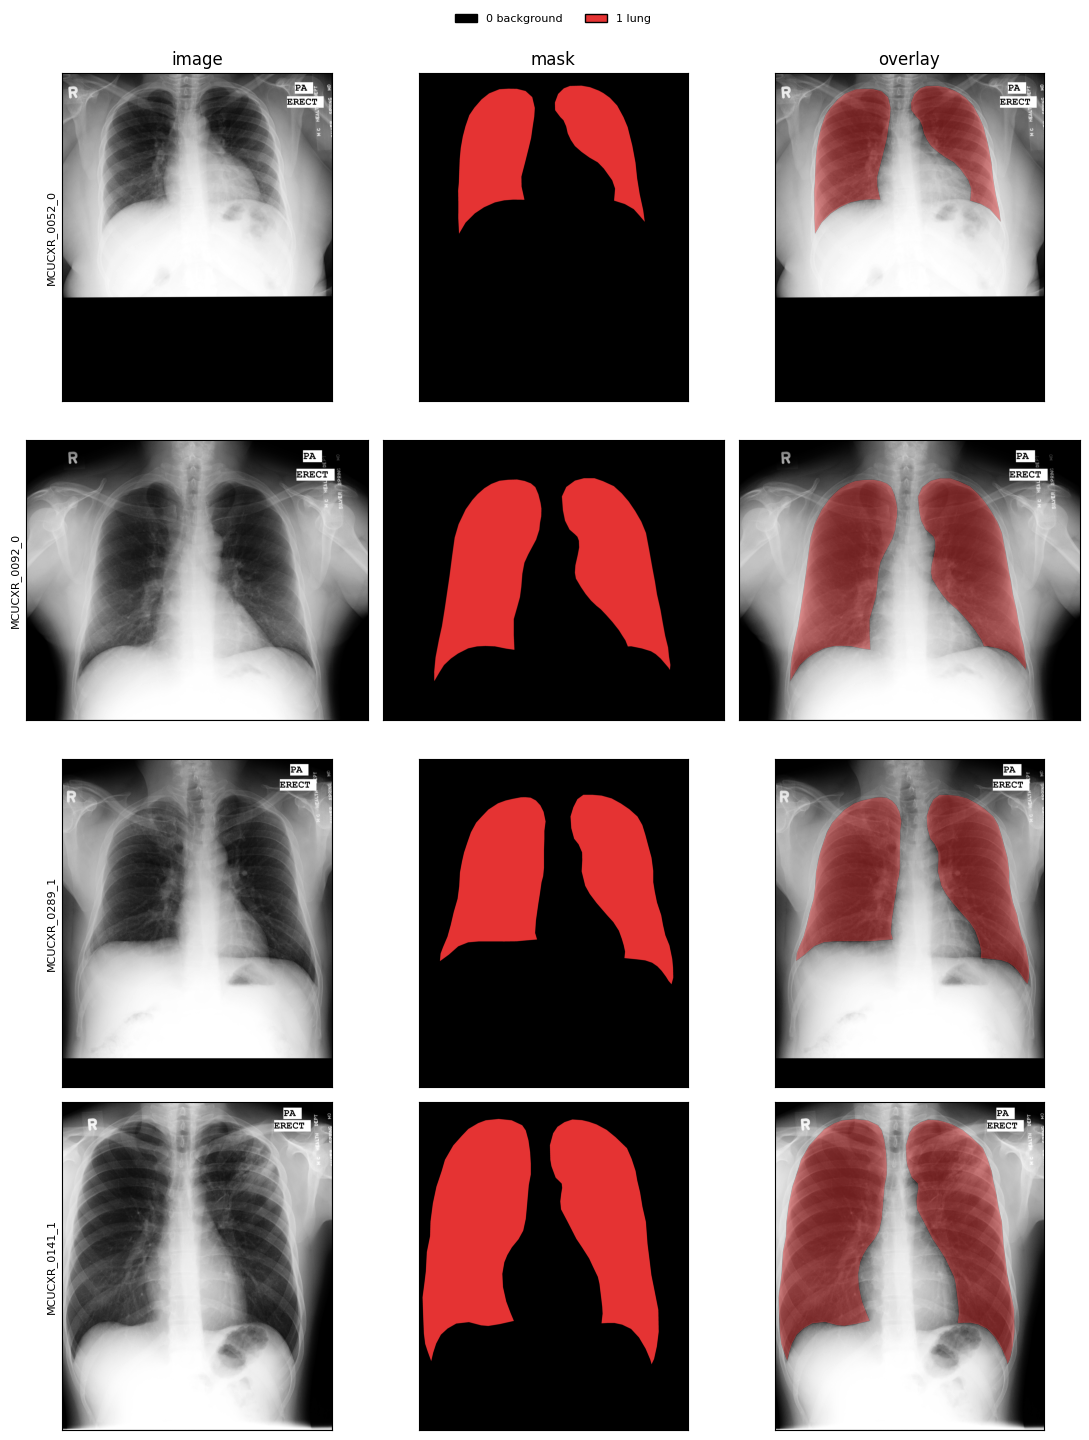

In [7]:
show_samples(n=4, seed=0)

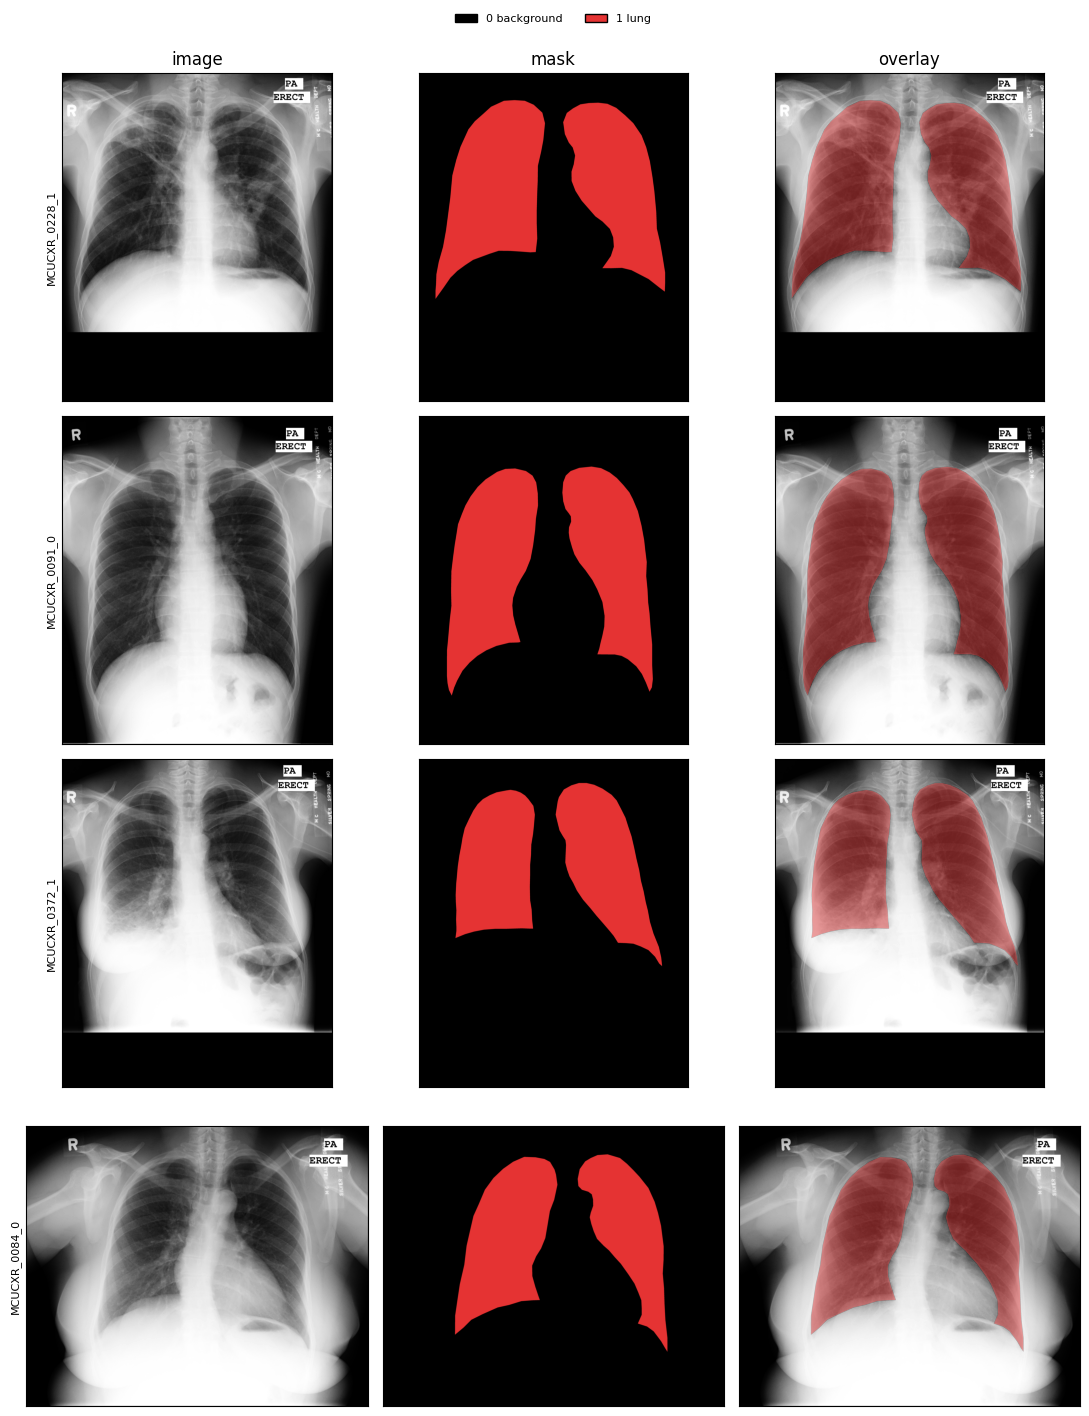

In [8]:
show_samples(n=4, seed=1)